In [1]:
import numpy as np
import pandas as pd

In [2]:
df = pd.read_csv("spam.csv", encoding="latin1")

In [3]:
df.sample(5)

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
4197,spam,Want to funk up ur fone with a weekly new tone...,NaN,NaN,NaN
4085,ham,Lemme know when you're here,NaN,NaN,NaN
3950,ham,Hi dude hw r u da realy mising u today,NaN,NaN,NaN
1628,ham,Yes princess! I want to make you happy...,NaN,NaN,NaN
2855,ham,"Japanese Proverb: If one Can do it, U too Can ...",NaN,NaN,NaN


In [4]:
df.shape

(5572, 5)

In [5]:
# DATA CLEANING 
df.info


<bound method DataFrame.info of         v1                                                 v2 Unnamed: 2  \
0      ham  Go until jurong point, crazy.. Available only ...        NaN   
1      ham                      Ok lar... Joking wif u oni...        NaN   
2     spam  Free entry in 2 a wkly comp to win FA Cup fina...        NaN   
3      ham  U dun say so early hor... U c already then say...        NaN   
4      ham  Nah I don't think he goes to usf, he lives aro...        NaN   
...    ...                                                ...        ...   
5567  spam  This is the 2nd time we have tried 2 contact u...        NaN   
5568   ham              Will Ì_ b going to esplanade fr home?        NaN   
5569   ham  Pity, * was in mood for that. So...any other s...        NaN   
5570   ham  The guy did some bitching but I acted like i'd...        NaN   
5571   ham                         Rofl. Its true to its name        NaN   

     Unnamed: 3 Unnamed: 4  
0           NaN        NaN

In [6]:
# drop last 3 columns
df.drop(columns=['Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'], inplace = True)
df.sample(5)

,v1,v2
3422,spam,Had your mobile 10 mths? Update to latest Oran...
356,spam,Congratulations ur awarded 500 of CD vouchers ...
1934,ham,Hope you are having a great day.
1256,ham,"Not yet chikku..going to room nw, i'm in bus.."
2412,spam,I don't know u and u don't know me. Send CHAT ...


In [7]:
# renaming the columns
df.rename(columns={'v1' : 'target', 'v2' : 'text'},inplace = True)
df.sample(5)

,target,text
2848,spam,YOUR CHANCE TO BE ON A REALITY FANTASY SHOW ca...
1541,ham,Do u konw waht is rael FRIENDSHIP Im gving yuo...
5054,ham,Am on a train back from northampton so i'm afr...
1934,ham,Hope you are having a great day.
3839,ham,HEY MATE! HOWS U HONEY?DID U AVE GOOD HOLIDAY?...


In [8]:
df.head()

,target,text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [9]:
# missing values
df.isnull().sum()

target    0
text      0
dtype: int64

In [10]:
# check for duplicate values
df.duplicated().sum()


np.int64(403)

In [11]:
# remove duplicate values
df = df.drop_duplicates(keep = 'first')
df.duplicated().sum()

np.int64(0)

In [12]:
df.shape

(5169, 2)

In [13]:
#EDA - EXPLORATORY DATA ANALYSIS
df.head()

,target,text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [14]:
df['target'].value_counts()

target
ham     4516
spam     653
Name: count, dtype: int64

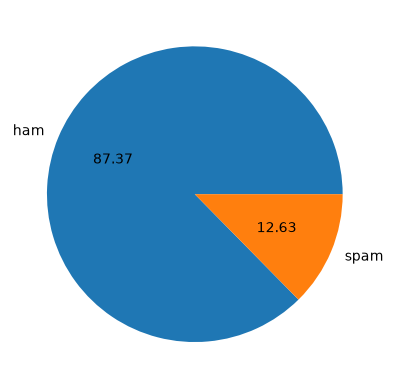

In [15]:
import matplotlib.pyplot as plt
plt.pie(df['target'].value_counts(), labels= ['ham','spam'],autopct= "%0.2f" )
plt.show()

In [16]:
import nltk
nltk.download('punkt')


[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\shrey\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [17]:
df['num_characters'] = df['text'].apply(len)

In [18]:
df.head()

,target,text,num_characters
0,ham,"Go until jurong point, crazy.. Available only ...",111
1,ham,Ok lar... Joking wif u oni...,29
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,155
3,ham,U dun say so early hor... U c already then say...,49
4,ham,"Nah I don't think he goes to usf, he lives aro...",61


In [19]:
import nltk
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\shrey\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [20]:
df['text'].apply(lambda x: nltk.word_tokenize(x))

0       [Go, until, jurong, point, ,, crazy, .., Avail...
1                [Ok, lar, ..., Joking, wif, u, oni, ...]
2       [Free, entry, in, 2, a, wkly, comp, to, win, F...
3       [U, dun, say, so, early, hor, ..., U, c, alrea...
4       [Nah, I, do, n't, think, he, goes, to, usf, ,,...
                              ...                        
5567    [This, is, the, 2nd, time, we, have, tried, 2,...
5568     [Will, Ì_, b, going, to, esplanade, fr, home, ?]
5569    [Pity, ,, *, was, in, mood, for, that, ., So, ...
5570    [The, guy, did, some, bitching, but, I, acted,...
5571                  [Rofl, ., Its, true, to, its, name]
Name: text, Length: 5169, dtype: object

In [21]:
df['num_words']=df['text'].apply(lambda x: len(nltk.word_tokenize(x)))

In [22]:
df.head()

,target,text,num_characters,num_words
0,ham,"Go until jurong point, crazy.. Available only ...",111,24
1,ham,Ok lar... Joking wif u oni...,29,8
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,155,37
3,ham,U dun say so early hor... U c already then say...,49,13
4,ham,"Nah I don't think he goes to usf, he lives aro...",61,15


In [23]:
df['text'].apply(lambda x: nltk.sent_tokenize(x))

0       [Go until jurong point, crazy.., Available onl...
1                        [Ok lar..., Joking wif u oni...]
2       [Free entry in 2 a wkly comp to win FA Cup fin...
3       [U dun say so early hor... U c already then sa...
4       [Nah I don't think he goes to usf, he lives ar...
                              ...                        
5567    [This is the 2nd time we have tried 2 contact ...
5568              [Will Ì_ b going to esplanade fr home?]
5569    [Pity, * was in mood for that., So...any other...
5570    [The guy did some bitching but I acted like i'...
5571                        [Rofl., Its true to its name]
Name: text, Length: 5169, dtype: object

In [24]:
df['num_sentences']=df['text'].apply(lambda x: len(nltk.sent_tokenize(x)))

In [25]:
df.head()

,target,text,num_characters,num_words,num_sentences
0,ham,"Go until jurong point, crazy.. Available only ...",111,24,2
1,ham,Ok lar... Joking wif u oni...,29,8,2
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2
3,ham,U dun say so early hor... U c already then say...,49,13,1
4,ham,"Nah I don't think he goes to usf, he lives aro...",61,15,1


In [26]:
df[['num_characters', 'num_words', 'num_sentences']]. describe()

,num_characters,num_words,num_sentences
count,5169.000000,5169.000000,5169.000000
mean,78.977945,18.455794,1.965564
std,58.236293,13.324758,1.448541
min,2.000000,1.000000,1.000000
25%,36.000000,9.000000,1.000000
50%,60.000000,15.000000,1.000000
75%,117.000000,26.000000,2.000000
max,910.000000,220.000000,38.000000


In [27]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()
df['target'] = encoder.fit_transform(df['target'])

In [28]:
# ham
df[df['target']== 0][['num_characters', 'num_words', 'num_sentences']]. describe()

,num_characters,num_words,num_sentences
count,4516.000000,4516.000000,4516.000000
mean,70.459256,17.123782,1.820195
std,56.358207,13.493970,1.383657
min,2.000000,1.000000,1.000000
25%,34.000000,8.000000,1.000000
50%,52.000000,13.000000,1.000000
75%,90.000000,22.000000,2.000000
max,910.000000,220.000000,38.000000


In [29]:
# spam
df[df['target']== 1][['num_characters', 'num_words', 'num_sentences']]. describe()

,num_characters,num_words,num_sentences
count,653.000000,653.000000,653.000000
mean,137.891271,27.667688,2.970904
std,30.137753,7.008418,1.488425
min,13.000000,2.000000,1.000000
25%,132.000000,25.000000,2.000000
50%,149.000000,29.000000,3.000000
75%,157.000000,32.000000,4.000000
max,224.000000,46.000000,9.000000


<Axes: xlabel='num_characters', ylabel='Count'>

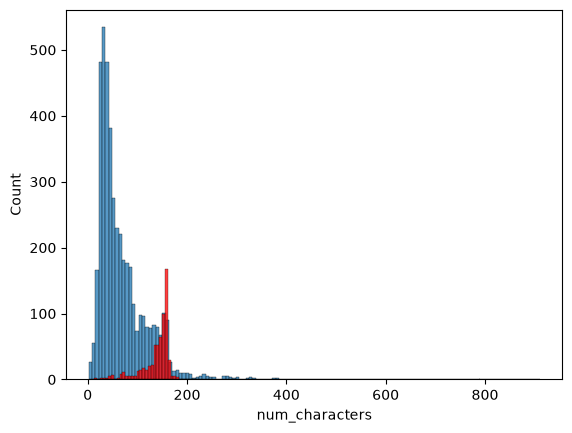

In [30]:
import seaborn as sns
sns.histplot(df[df['target']==0]['num_characters'])
sns.histplot(df[df['target']==1]['num_characters'], color = 'red')


<Axes: xlabel='num_words', ylabel='Count'>

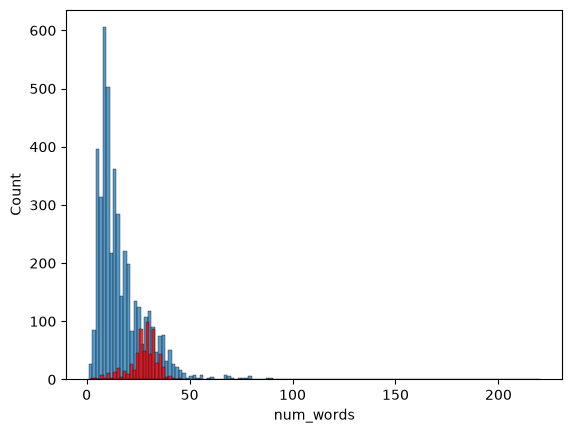

In [31]:
import seaborn as sns
sns.histplot(df[df['target']==0]['num_words'])
sns.histplot(df[df['target']==1]['num_words'], color = 'red')


<Axes: xlabel='num_sentences', ylabel='Count'>

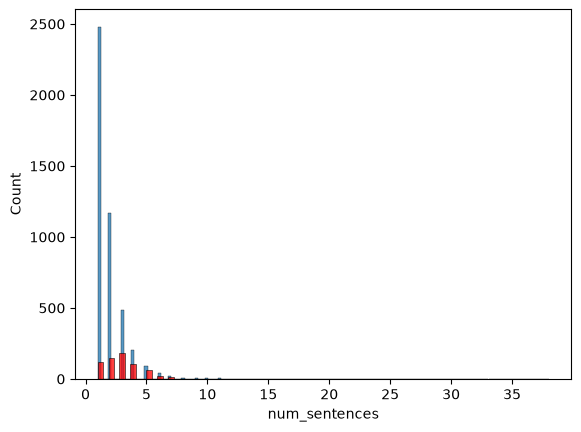

In [32]:
import seaborn as sns
sns.histplot(df[df['target']==0]['num_sentences'])
sns.histplot(df[df['target']==1]['num_sentences'], color = 'red')


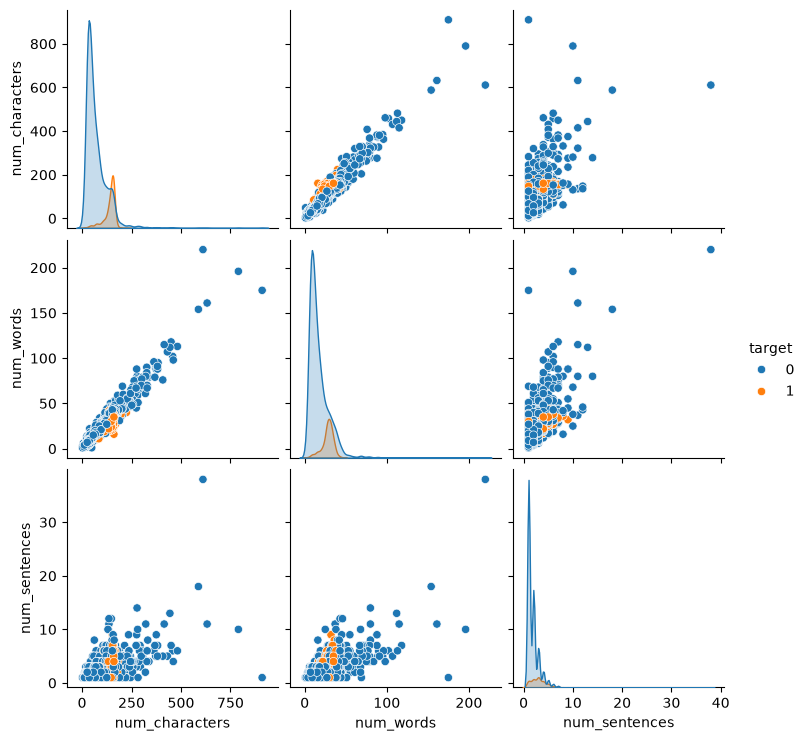

In [33]:
sns.pairplot(df,hue='target')

In [34]:
df.corr(numeric_only=True)

,target,num_characters,num_words,num_sentences
target,1.000000,0.384717,0.262912,0.263939
num_characters,0.384717,1.000000,0.965760,0.624139
num_words,0.262912,0.965760,1.000000,0.679971
num_sentences,0.263939,0.624139,0.679971,1.000000


<Axes: >

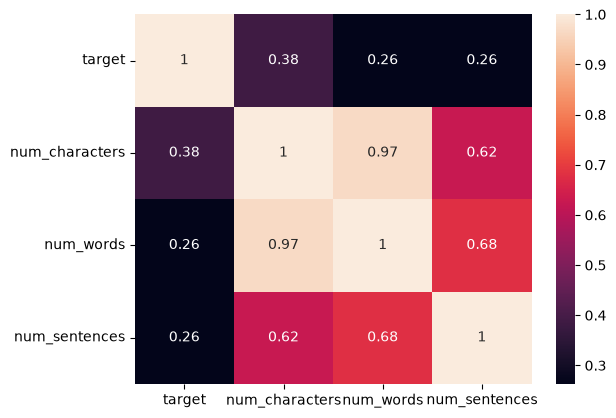

In [35]:
sns.heatmap(df.corr(numeric_only=True), annot = True)

In [76]:
#data preprocessing:
# lower case
# tokenization
# removing special characters
# removing stop words and punctuations
#stemming


In [38]:
def transform_text(text):
    text = text.lower()
    text = nltk.word_tokenize(text)

    y = []

    for i in text:
        if i.isalnum():
            y.append(i)

    text = y[:]
    y.clear()

    for i in text:
        if i not in stopwords.words('english') and i not in string.punctuation:
            y.append(i)

    text = y[:]
    y.clear()

    for i in text:
        y.append(ps.stem(i))

    return " ".join(y)

In [39]:
import nltk
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\shrey\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [40]:
from nltk.corpus import stopwords
stopwords.words('english')

['a',
 'about',
 'above',
 'after',
 'again',
 'against',
 'ain',
 'all',
 'am',
 'an',
 'and',
 'any',
 'are',
 'aren',
 "aren't",
 'as',
 'at',
 'be',
 'because',
 'been',
 'before',
 'being',
 'below',
 'between',
 'both',
 'but',
 'by',
 'can',
 'couldn',
 "couldn't",
 'd',
 'did',
 'didn',
 "didn't",
 'do',
 'does',
 'doesn',
 "doesn't",
 'doing',
 'don',
 "don't",
 'down',
 'during',
 'each',
 'few',
 'for',
 'from',
 'further',
 'had',
 'hadn',
 "hadn't",
 'has',
 'hasn',
 "hasn't",
 'have',
 'haven',
 "haven't",
 'having',
 'he',
 "he'd",
 "he'll",
 'her',
 'here',
 'hers',
 'herself',
 "he's",
 'him',
 'himself',
 'his',
 'how',
 'i',
 "i'd",
 'if',
 "i'll",
 "i'm",
 'in',
 'into',
 'is',
 'isn',
 "isn't",
 'it',
 "it'd",
 "it'll",
 "it's",
 'its',
 'itself',
 "i've",
 'just',
 'll',
 'm',
 'ma',
 'me',
 'mightn',
 "mightn't",
 'more',
 'most',
 'mustn',
 "mustn't",
 'my',
 'myself',
 'needn',
 "needn't",
 'no',
 'nor',
 'not',
 'now',
 'o',
 'of',
 'off',
 'on',
 'once',
 'on

In [41]:
import string
string.punctuation

'!"#$%&\'()*+,-./:;<=>?@[\\]^_`{|}~'

In [43]:
from nltk.stem.porter import PorterStemmer
ps = PorterStemmer()
ps.stem('dancing')

'danc'

In [46]:
transform_text('HI, HOW ARE YOU?I ScorEd 20 %% in mAths')

'hi score 20 math'

In [47]:
ps.stem('loving')

'love'

In [48]:
transform_text('HI, HOW ARE YOU?I Loved the Youtube lectures on Machine learning. How about you?')

'hi love youtub lectur machin learn'

In [49]:
df['text'][10]

"I'm gonna be home soon and i don't want to talk about this stuff anymore tonight, k? I've cried enough today."

In [50]:
transform_text("I'm gonna be home soon and i don't want to talk about this stuff anymore tonight, k? I've cried enough today.")

'gon na home soon want talk stuff anymor tonight k cri enough today'

In [51]:
df['transformed_text'] = df['text']. apply(transform_text)

In [52]:
df.head()

,target,text,num_characters,num_words,num_sentences,transformed_text
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2,go jurong point crazi avail bugi n great world...
1,0,Ok lar... Joking wif u oni...,29,8,2,ok lar joke wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2,free entri 2 wkli comp win fa cup final tkt 21...
3,0,U dun say so early hor... U c already then say...,49,13,1,u dun say earli hor u c alreadi say
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1,nah think goe usf live around though


In [53]:
df['transformed_text'] = df['transformed_text'].apply(lambda x: " ".join(x) if isinstance(x, list) else x)

In [54]:
from wordcloud import WordCloud

wc = WordCloud(
    width=500,
    height=500,
    min_font_size=10,
    background_color='black'
)

(np.float64(-0.5), np.float64(499.5), np.float64(499.5), np.float64(-0.5))

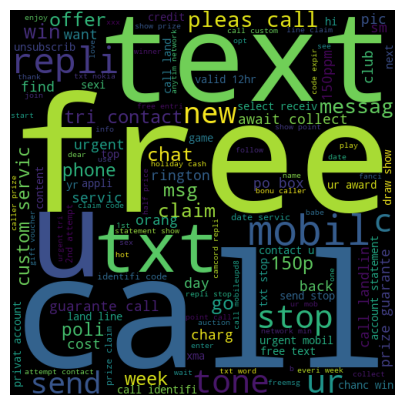

In [55]:
spam_wc = wc.generate(df[df['target']==1]['transformed_text'].str.cat(sep=" "))

plt.figure(figsize=(10,5))
plt.imshow(spam_wc)
plt.axis("off")

(np.float64(-0.5), np.float64(499.5), np.float64(499.5), np.float64(-0.5))

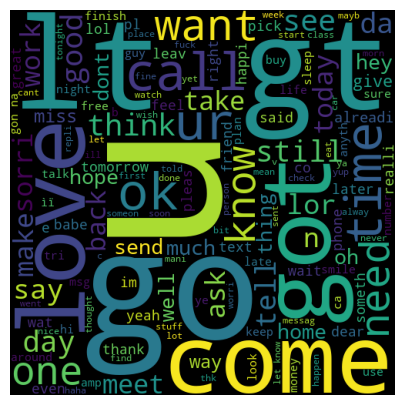

In [56]:
ham_wc = wc.generate(df[df['target']==0]['transformed_text'].str.cat(sep=" "))

plt.figure(figsize=(10,5))
plt.imshow(ham_wc)
plt.axis("off")

In [57]:
for msg in df[df['target']== 1]['transformed_text']. tolist():
    print (msg)

free entri 2 wkli comp win fa cup final tkt 21st may text fa 87121 receiv entri question std txt rate c appli 08452810075over18
freemsg hey darl 3 week word back like fun still tb ok xxx std chg send rcv
winner valu network custom select receivea prize reward claim call claim code kl341 valid 12 hour
mobil 11 month u r entitl updat latest colour mobil camera free call mobil updat co free 08002986030
six chanc win cash 100 pound txt csh11 send cost 6day tsandc appli repli hl 4 info
urgent 1 week free membership prize jackpot txt word claim 81010 c lccltd pobox 4403ldnw1a7rw18
xxxmobilemovieclub use credit click wap link next txt messag click http
england v macedonia dont miss news txt ur nation team 87077 eg england 87077 tri wale scotland poboxox36504w45wq
thank subscript rington uk mobil charg pleas confirm repli ye repli charg
07732584351 rodger burn msg tri call repli sm free nokia mobil free camcord pleas call 08000930705 deliveri tomorrow
sm ac sptv new jersey devil detroit red wi

In [58]:
spam_corpus = []
for msg in df[df['target']== 1]['transformed_text']. tolist():
    for word in msg.split():
        spam_corpus.append(word)

In [59]:
len(spam_corpus)

9939

In [60]:
from collections import Counter
pd.DataFrame(Counter(spam_corpus).most_common(30))

,0,1
0,call,320
1,free,191
2,2,155
3,txt,141
4,text,122
5,u,119
6,ur,119
7,mobil,114
8,stop,104
9,repli,103


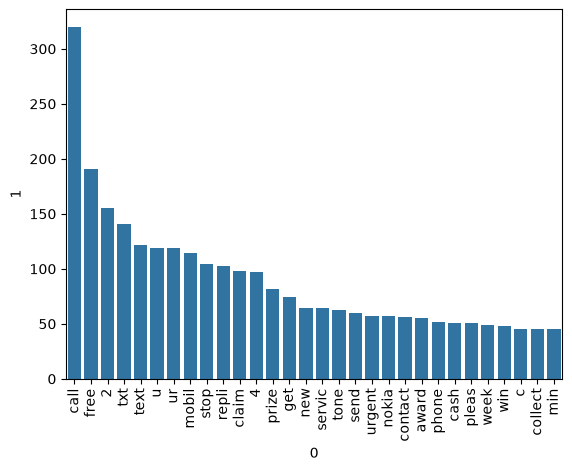

In [61]:
from collections import Counter

common_words = pd.DataFrame(Counter(spam_corpus).most_common(30))

sns.barplot(
    x=common_words[0],
    y=common_words[1]
)

plt.xticks(rotation='vertical')
plt.show()

In [62]:
ham_corpus = []
for msg in df[df['target']== 0]['transformed_text']. tolist():
    for word in msg.split():
        ham_corpus.append(word)

In [63]:
len(ham_corpus)

35404

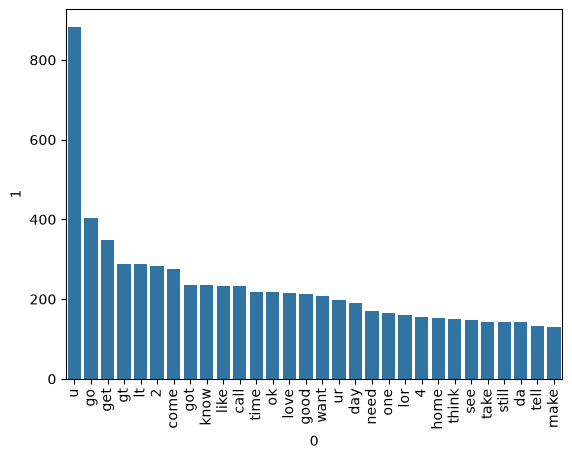

In [64]:
from collections import Counter

common_words = pd.DataFrame(Counter(ham_corpus).most_common(30))

sns.barplot(
    x=common_words[0],
    y=common_words[1]
)

plt.xticks(rotation='vertical')
plt.show()

In [65]:
#MODEL BUILDING
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
tfidf = TfidfVectorizer(max_features=3000)
cv = CountVectorizer()
X = cv.fit_transform(df['transformed_text']).toarray()

In [66]:
x = tfidf.fit_transform(df['transformed_text']).toarray()
x.shape

(5169, 3000)

In [67]:
X.shape

(5169, 6708)

In [68]:
Y = df['target'].values

In [69]:
y = df['target'].values

In [70]:
Y

array([0, 0, 1, ..., 0, 0, 0], shape=(5169,))

In [71]:
X

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], shape=(5169, 6708))

In [72]:
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB, MultinomialNB, BernoulliNB
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score

# Split the data
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.2, random_state=2
)

# Create the model
gnb = GaussianNB()

# Train the model
gnb.fit(X_train, Y_train)

# Predict
Y_pred1 = gnb.predict(X_test)

# Evaluate
print("Accuracy:", accuracy_score(Y_test, Y_pred1))
print("Confusion Matrix:\n", confusion_matrix(Y_test, Y_pred1))
print("Precision:", precision_score(Y_test, Y_pred1))

Accuracy: 0.8800773694390716
Confusion Matrix:
 [[792 104]
 [ 20 118]]
Precision: 0.5315315315315315


In [73]:
# Create the model
mnb = MultinomialNB()

# Train the model
mnb.fit(X_train, Y_train)

# Predict
Y_pred2 = mnb.predict(X_test)

# Evaluate
print("Accuracy:", accuracy_score(Y_test, Y_pred2))
print("Confusion Matrix:\n", confusion_matrix(Y_test, Y_pred2))
print("Precision:", precision_score(Y_test, Y_pred2))

Accuracy: 0.9642166344294004
Confusion Matrix:
 [[871  25]
 [ 12 126]]
Precision: 0.8344370860927153


In [74]:
# Create the model
bnb = BernoulliNB()

# Train the model
bnb.fit(X_train, Y_train)

# Predict
Y_pred3 = bnb.predict(X_test)

# Evaluate
print("Accuracy:", accuracy_score(Y_test, Y_pred3))
print("Confusion Matrix:\n", confusion_matrix(Y_test, Y_pred3))
print("Precision:", precision_score(Y_test, Y_pred3))

Accuracy: 0.9700193423597679
Confusion Matrix:
 [[893   3]
 [ 28 110]]
Precision: 0.9734513274336283


In [75]:
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score

# Split the data
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=2
)

# Create the model
gnb = GaussianNB()

# Train the model
gnb.fit(x_train, y_train)

# Predict
y_pred1 = gnb.predict(x_test)

# Evaluate
print("Accuracy:", accuracy_score(y_test, y_pred1))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred1))
print("Precision:", precision_score(y_test, y_pred1))

Accuracy: 0.874274661508704
Confusion Matrix:
 [[790 106]
 [ 24 114]]
Precision: 0.5181818181818182


In [76]:
# Create the model
mnb = MultinomialNB()

# Train the model
mnb.fit(x_train, y_train)

# Predict
y_pred2 = mnb.predict(x_test)

# Evaluate
print("Accuracy:", accuracy_score(y_test, y_pred2))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred2))
print("Precision:", precision_score(y_test, y_pred2))

Accuracy: 0.9709864603481625
Confusion Matrix:
 [[896   0]
 [ 30 108]]
Precision: 1.0


In [77]:
# Create the model
bnb = BernoulliNB()

# Train the model
bnb.fit(x_train, y_train)

# Predict
y_pred3 = bnb.predict(x_test)

# Evaluate
print("Accuracy:", accuracy_score(y_test, y_pred3))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred3))
print("Precision:", precision_score(y_test, y_pred3))

Accuracy: 0.9835589941972921
Confusion Matrix:
 [[895   1]
 [ 16 122]]
Precision: 0.991869918699187


In [78]:
import pickle
pickle.dump(tfidf,open('vectorizer.pkl', 'wb'))
pickle.dump(mnb,open('model.pkl', 'wb'))

In [79]:
transform_text("Congratulations, You've won a lottery for Rs. 1000000, Register here to win")

'congratul lotteri rs 1000000 regist win'

In [80]:
text = "Congratulations, You've won a lottery for Rs. 1000000, Register here to win"

transformed = transform_text(text)
print(transformed)

congratul lotteri rs 1000000 regist win


In [81]:
vector = tfidf.transform([transformed])

In [82]:
print(mnb.predict(vector))

[0]


In [83]:
mnb

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
Name,Type,Value
"class_count_ class_count_: ndarray of shape (n_classes,)Number of samples encountered for each class during fitting. Thisvalue is weighted by the sample weight when provided.","ndarray[float64](2,)","[3620., 515.]"
"class_log_prior_ class_log_prior_: ndarray of shape (n_classes,)Smoothed empirical log probability for each class.","ndarray[float64](2,)","[-0.13,-2.08]"
"classes_ classes_: ndarray of shape (n_classes,)Class labels known to the classifier","ndarray[int64](2,)","[0,1]"
"feature_count_ feature_count_: ndarray of shape (n_classes, n_features)Number of samples encountered for each (class, feature)during fitting. This value is weighted by the sample weight whenprovided.","ndarray[float64](2, 3000)","[[ 0. , 0. , 0. ,..., 0. , 0.38,16.22], [ 0.35, 0.81, 0.66,..., 1.07, 0. , 0. ]]"
"feature_log_prob_ feature_log_prob_: ndarray of shape (n_classes, n_features)Empirical log probability of featuresgiven a class, ``P(x_i|y)``.","ndarray[float64](2, 3000)","[[-9.34,-9.34,-9.34,...,-9.34,-9.02,-6.5 ], [-8.16,-7.86,-7.95,...,-7.73,-8.46,-8.46]]"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,3000


In [84]:
df['target'].value_counts()

target
0    4516
1     653
Name: count, dtype: int64

In [85]:
texts = [
    "FREE entry in 2 a wkly comp to win FA Cup final tickets",
    "URGENT! You have won a 1 week FREE membership. Call now!",
    "Congratulations! Claim your prize now by calling this number.",
    "Hey, are we still meeting at 6?"
]

for t in texts:
    transformed = transform_text(t)
    vector = tfidf.transform([transformed])
    print(t)
    print(mnb.predict(vector))
    print("-" * 30)

FREE entry in 2 a wkly comp to win FA Cup final tickets
[1]
------------------------------
URGENT! You have won a 1 week FREE membership. Call now!
[1]
------------------------------
Congratulations! Claim your prize now by calling this number.
[1]
------------------------------
Hey, are we still meeting at 6?
[0]
------------------------------
